In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
sns.set_palette("Set2")

In [20]:
df = pd.read_csv("titanicdataset.csv")

print("First 5 rows:")
df.head()

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


Shape: (891, 12)

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

In [10]:
df['Sex'] = df['Sex'].map({'male': 'Male', 'female': 'Female'})

df['Pclass'] = df['Pclass'].map({
    1: 'First Class',
    2: 'Second Class',
    3: 'Third Class'
})


In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch']

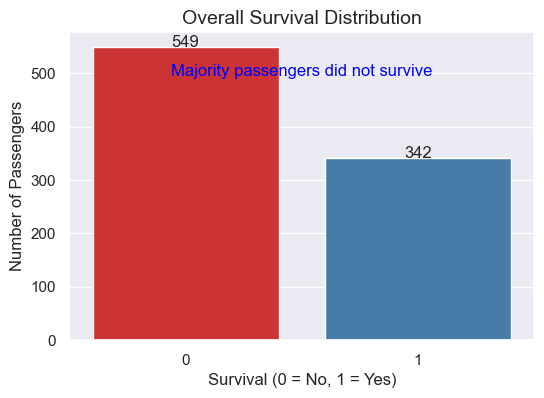

In [12]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Survived', hue='Survived', data=df, palette='Set1', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center')

plt.title("Overall Survival Distribution", fontsize=14)
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.text(0.5, max([p.get_height() for p in ax.patches])*0.9,
         "Majority passengers did not survive",
         ha='center', color='blue')

plt.show()

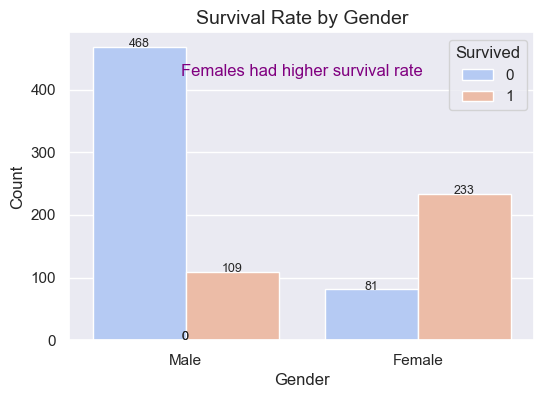

In [13]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Sex', hue='Survived', data=df, palette='coolwarm')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', fontsize=9)

plt.title("Survival Rate by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Survived")

plt.text(0.5, max([p.get_height() for p in ax.patches])*0.9,
         "Females had higher survival rate",
         ha='center', color='purple')

plt.show()


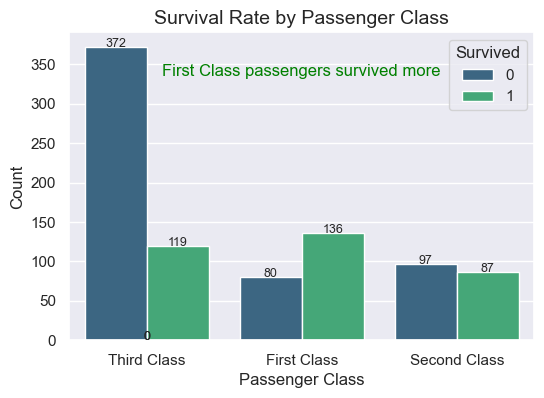

In [14]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', fontsize=9)

plt.title("Survival Rate by Passenger Class", fontsize=14)
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived")

plt.text(1, max([p.get_height() for p in ax.patches])*0.9,
         "First Class passengers survived more",
         ha='center', color='green')

plt.show()

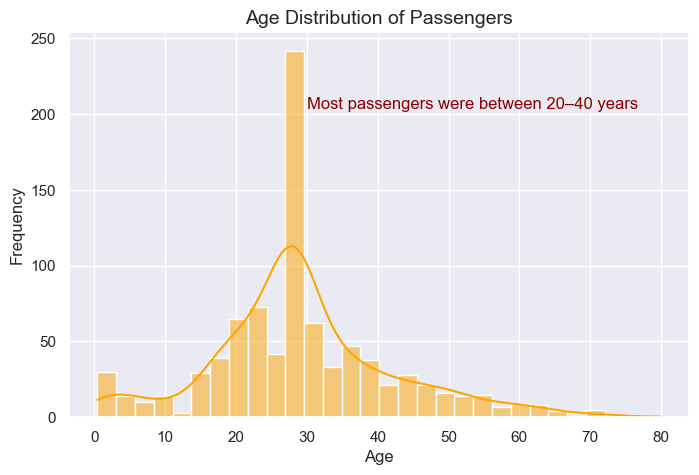

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='orange')

plt.title("Age Distribution of Passengers", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.text(30, plt.ylim()[1]*0.8,
         "Most passengers were between 20–40 years",
         color='darkred')

plt.show()

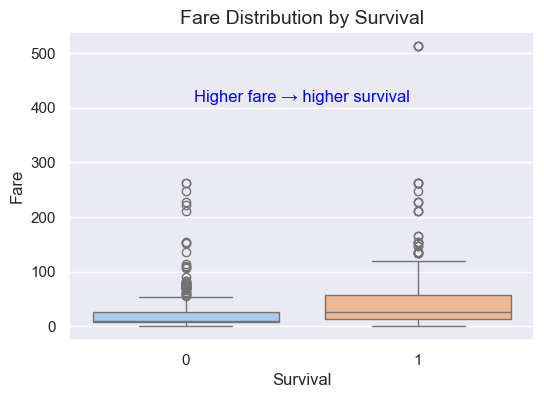

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Fare', hue='Survived', data=df, palette='pastel', legend=False)

plt.title("Fare Distribution by Survival", fontsize=14)
plt.xlabel("Survival")
plt.ylabel("Fare")

plt.text(0.5, df['Fare'].max()*0.8,
         "Higher fare → higher survival",
         ha='center', color='blue')

plt.show()

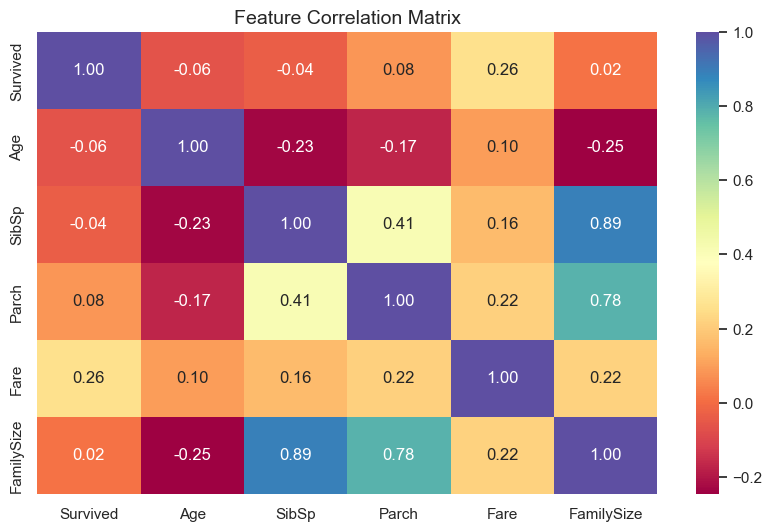

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Spectral', fmt=".2f")

plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()


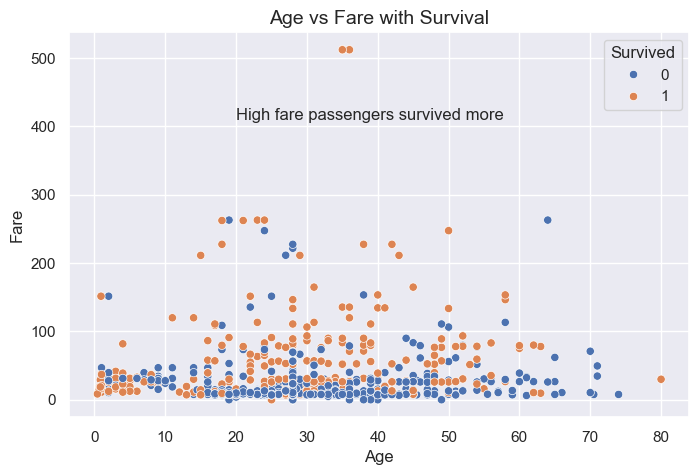

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, palette='deep')

plt.title("Age vs Fare with Survival", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Fare")

plt.text(20, df['Fare'].max()*0.8,
         "High fare passengers survived more")

plt.show()

In [19]:
print("\nFINAL INSIGHTS:")
print("1. Females had higher survival rate")
print("2. First class passengers survived more")
print("3. Higher fare increased survival chances")
print("4. Most passengers were young adults")
print("5. Family size impacts survival probability")


FINAL INSIGHTS:
1. Females had higher survival rate
2. First class passengers survived more
3. Higher fare increased survival chances
4. Most passengers were young adults
5. Family size impacts survival probability
